# 04 Cohort Retention

This notebook builds a monthly cohort retention analysis using each user's first observed event month.

## 1. Import libraries and define file paths

We import the libraries we need and set the input and output paths for the cohort analysis files.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_PATH = Path("..") / "outputs" / "events_cleaned.csv"
OUTPUT_DIR = Path("..") / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COHORT_COUNTS_OUTPUT = OUTPUT_DIR / "cohort_counts.csv"
COHORT_MATRIX_OUTPUT = OUTPUT_DIR / "cohort_retention_matrix.csv"
COHORT_PERCENTAGES_OUTPUT = OUTPUT_DIR / "cohort_retention_percentages.csv"

sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (12, 7)

print(f"Input file: {INPUT_PATH.resolve()}")

Input file: C:\Users\jayso\.vscode\internships projects\product_analytics_cohort\outputs\events_cleaned.csv


## 2. Load the cleaned dataset

We read the cleaned dataset from the `outputs` folder.

In [2]:
df = pd.read_csv(INPUT_PATH, parse_dates=["event_time"])
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Briefly inspect the dataset for cohort work

We only need a few fields for cohort retention: the user identifier and the event month.

In [3]:
print("Shape:", df.shape)
print("Unique users:", df["user_id"].nunique())
print("Event month range:", df["event_month"].min(), "to", df["event_month"].max())
df[["user_id", "event_time", "event_month"]].head()

Shape: (884474, 12)
Unique users: 407283
Event month range: 2020-09 to 2021-02


,user_id,event_time,event_month
0,1515915625519388267,2020-09-24 11:57:06+00:00,2020-09
1,1515915625519380411,2020-09-24 11:57:26+00:00,2020-09
2,1515915625513238515,2020-09-24 11:57:27+00:00,2020-09
3,1515915625519014356,2020-09-24 11:57:33+00:00,2020-09
4,1515915625510743344,2020-09-24 11:57:36+00:00,2020-09


## 4. Create one monthly activity record per user

For retention analysis, we only need to know whether a user was active in a given month, not how many events they generated.

In [4]:
user_month_activity = df[["user_id", "event_month"]].drop_duplicates().copy()
print("User-month activity rows:", len(user_month_activity))

User-month activity rows: 420149


## 5. Assign each user to a cohort month

We define the cohort as the month of the user's first observed event in the dataset.

In [5]:
user_cohorts = (
    user_month_activity.groupby("user_id")["event_month"]
    .min()
    .reset_index()
    .rename(columns={"event_month": "cohort_month"})
)

user_cohorts.head()

,user_id,cohort_month
0,1515915625353226922,2020-10
1,1515915625353230067,2020-10
2,1515915625353230683,2020-11
3,1515915625353230922,2020-10
4,1515915625353234047,2020-09


## 6. Combine cohort month with user activity month

This lets us compare when a user joined with when the same user returned in later months.

In [6]:
cohort_data = user_month_activity.merge(user_cohorts, on="user_id", how="left")
cohort_data.head()

,user_id,event_month,cohort_month
0,1515915625519388267,2020-09,2020-09
1,1515915625519380411,2020-09,2020-09
2,1515915625513238515,2020-09,2020-09
3,1515915625519014356,2020-09,2020-09
4,1515915625510743344,2020-09,2020-09


## 7. Calculate the month number for each cohort record

Month `0` is the cohort month itself, month `1` is the next month, and so on.

In [7]:
cohort_data["event_month_period"] = pd.PeriodIndex(cohort_data["event_month"], freq="M")
cohort_data["cohort_month_period"] = pd.PeriodIndex(cohort_data["cohort_month"], freq="M")
cohort_data["cohort_index"] = (
    cohort_data["event_month_period"] - cohort_data["cohort_month_period"]
).apply(lambda x: x.n)

cohort_data[["user_id", "cohort_month", "event_month", "cohort_index"]].head()

,user_id,cohort_month,event_month,cohort_index
0,1515915625519388267,2020-09,2020-09,0
1,1515915625519380411,2020-09,2020-09,0
2,1515915625513238515,2020-09,2020-09,0
3,1515915625519014356,2020-09,2020-09,0
4,1515915625510743344,2020-09,2020-09,0


## 8. Count active users by cohort month and cohort index

This produces the main cohort counts table.

In [8]:
cohort_counts = (
    cohort_data.groupby(["cohort_month", "cohort_index"])["user_id"]
    .nunique()
    .reset_index(name="active_users")
    .sort_values(["cohort_month", "cohort_index"])
)

cohort_counts.head(10)

,cohort_month,cohort_index,active_users
0,2020-09,0,15334
1,2020-09,1,955
2,2020-09,2,267
3,2020-09,3,119
4,2020-09,4,98
5,2020-09,5,72
6,2020-10,0,83261
7,2020-10,1,2227
8,2020-10,2,678
9,2020-10,3,444


## 9. Build the cohort retention matrix

The retention matrix shows the number of active users for each cohort month across later months.

In [9]:
cohort_retention_matrix = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="active_users"
).sort_index()

cohort_retention_matrix

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2020-09,15334.0,955.0,267.0,119.0,98.0,72.0
2020-10,83261.0,2227.0,678.0,444.0,279.0,NaN
2020-11,90106.0,1867.0,792.0,552.0,NaN,NaN
2020-12,69473.0,1644.0,710.0,NaN,NaN,NaN
2021-01,78278.0,2162.0,NaN,NaN,NaN,NaN
2021-02,70831.0,NaN,NaN,NaN,NaN,NaN


## 10. Calculate retention percentages

We divide each row by the cohort size in month `0` so the table is easier to compare across cohorts.

In [10]:
cohort_sizes = cohort_retention_matrix[0]
cohort_retention_percentages = cohort_retention_matrix.divide(cohort_sizes, axis=0)
cohort_retention_percentages

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2020-09,1.0,0.062280,0.017412,0.007761,0.006391,0.004695
2020-10,1.0,0.026747,0.008143,0.005333,0.003351,NaN
2020-11,1.0,0.020720,0.008790,0.006126,NaN,NaN
2020-12,1.0,0.023664,0.010220,NaN,NaN,NaN
2021-01,1.0,0.027620,NaN,NaN,NaN,NaN
2021-02,1.0,NaN,NaN,NaN,NaN,NaN


## 11. Save the cohort outputs

These CSV files can be reused later for dashboarding and reporting.

In [11]:
cohort_counts.to_csv(COHORT_COUNTS_OUTPUT, index=False)
cohort_retention_matrix.to_csv(COHORT_MATRIX_OUTPUT)
cohort_retention_percentages.to_csv(COHORT_PERCENTAGES_OUTPUT)

print(f"Saved: {COHORT_COUNTS_OUTPUT.resolve()}")
print(f"Saved: {COHORT_MATRIX_OUTPUT.resolve()}")
print(f"Saved: {COHORT_PERCENTAGES_OUTPUT.resolve()}")

Saved: C:\Users\jayso\.vscode\internships projects\product_analytics_cohort\outputs\cohort_counts.csv
Saved: C:\Users\jayso\.vscode\internships projects\product_analytics_cohort\outputs\cohort_retention_matrix.csv
Saved: C:\Users\jayso\.vscode\internships projects\product_analytics_cohort\outputs\cohort_retention_percentages.csv


## 12. Visualize retention as a heatmap

This heatmap makes it easier to compare retention patterns across cohort months.

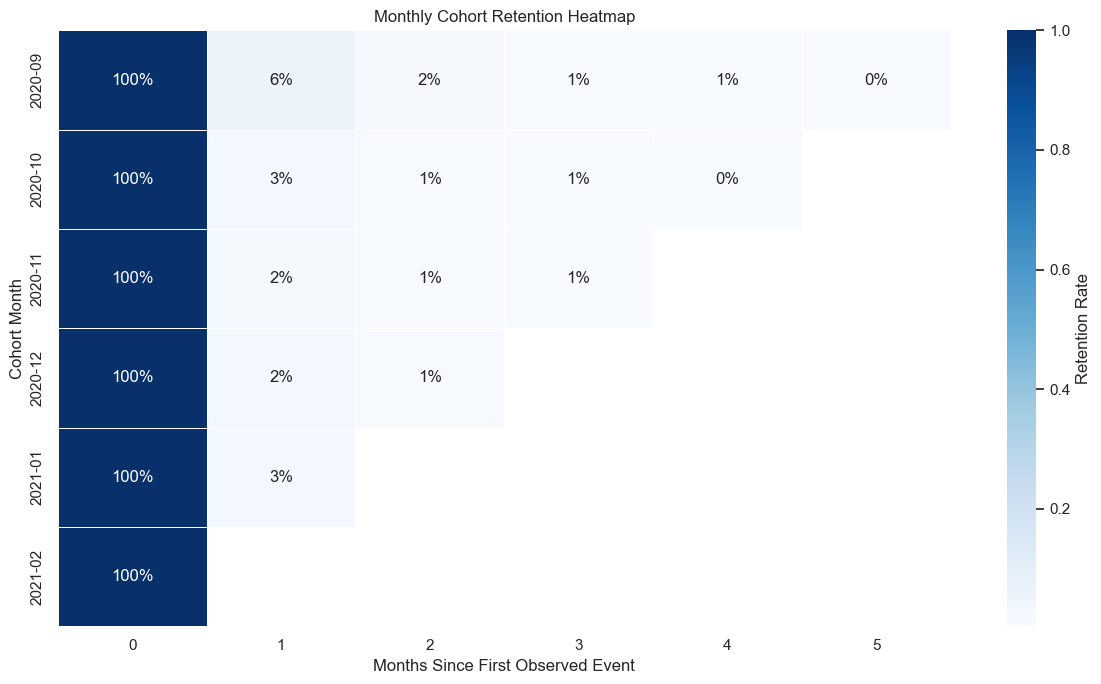

In [12]:
heatmap_data = cohort_retention_percentages.copy()

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Retention Rate"},
)
plt.title("Monthly Cohort Retention Heatmap")
plt.xlabel("Months Since First Observed Event")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

## 13. Print a short summary of the retention findings

This gives a simple text summary of the main retention results.

In [13]:
first_month_average = cohort_retention_percentages[1].mean()
second_month_average = cohort_retention_percentages[2].mean() if 2 in cohort_retention_percentages.columns else None
largest_cohort_month = cohort_sizes.idxmax()
largest_cohort_size = int(cohort_sizes.max())

print("Key Retention Findings")
print(f"- Number of cohort months analyzed: {cohort_retention_matrix.shape[0]}")
print(f"- Largest cohort month: {largest_cohort_month} ({largest_cohort_size:,} users)")
print(f"- Average month 1 retention: {first_month_average:.2%}")

if second_month_average is not None:
    print(f"- Average month 2 retention: {second_month_average:.2%}")

latest_full_cohort = cohort_retention_percentages.iloc[0]
print("- Cohort table and percentage outputs were saved to the outputs folder.")

Key Retention Findings
- Number of cohort months analyzed: 6
- Largest cohort month: 2020-11 (90,106 users)
- Average month 1 retention: 3.22%
- Average month 2 retention: 1.11%
- Cohort table and percentage outputs were saved to the outputs folder.
